In [1]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("feature_engineered_data.csv")
df.head()

,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


In [3]:
df_seg = df.copy()

features = df_seg[[
    'Engagement Rate (1-10)',
    'Daily Watch Time (Hours)',
    'Customer Satisfaction Score (1-10)'
]]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

##  Scale Data
We normalize values so all features contribute equally to clustering.


In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

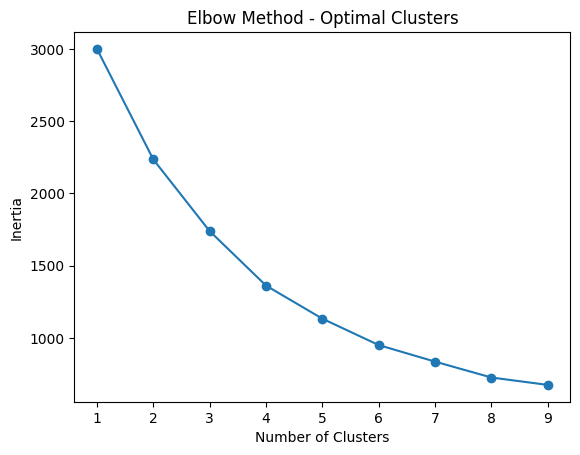

In [7]:
plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method - Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df_seg['Segment'] = kmeans.fit_predict(scaled_features)

df_seg[['Engagement Rate (1-10)', 
        'Daily Watch Time (Hours)', 
        'Customer Satisfaction Score (1-10)', 
        'Segment']].head()

,Engagement Rate (1-10),Daily Watch Time (Hours),Customer Satisfaction Score (1-10),Segment
0,4,4.85,10,2
1,9,1.75,8,0
2,9,2.75,4,1
3,9,3.00,7,1
4,5,1.37,2,0


In [9]:
df_seg['Segment'].value_counts()

Segment
2    357
0    336
1    307
Name: count, dtype: int64

## Segment Distribution

We check how users are distributed across clusters.

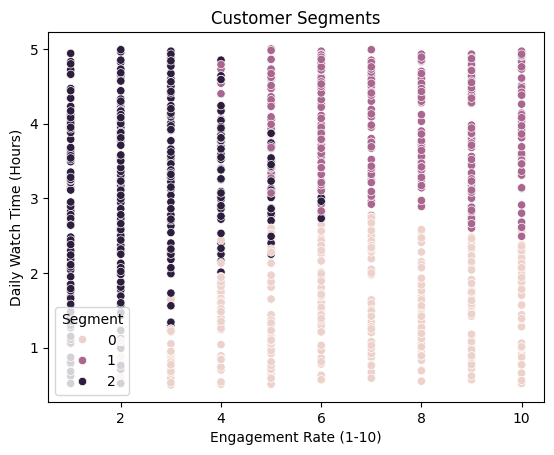

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x='Engagement Rate (1-10)',
    y='Daily Watch Time (Hours)',
    hue='Segment',
    data=df_seg
)

plt.title("Customer Segments")
plt.show()

In [11]:
segment_mean = df_seg.groupby('Segment')[[
    'Engagement Rate (1-10)',
    'Daily Watch Time (Hours)',
    'Customer Satisfaction Score (1-10)'
]].mean()

segment_mean

,Engagement Rate (1-10),Daily Watch Time (Hours),Customer Satisfaction Score (1-10)
Segment,,,
0,6.696429,1.473482,5.127976
1,7.680782,3.946482,4.879479
2,2.529412,3.144986,6.044818


## 📌 Segment Interpretation

Based on behavior:

- Segment 0 → Low engagement users (churn risk)
- Segment 1 → Medium users (average retention)
- Segment 2 → High engagement users (loyal customers)

---

## 💡 Business Value
- Target Segment 0 with retention campaigns
- Upsell Segment 1 users
- Reward Segment 2 for loyalty

In [13]:
df_seg['churn_flag'] = df_seg['Churn Status (Yes/No)'].map({'Yes': 1, 'No': 0})


In [14]:
df_seg.groupby('Segment')['churn_flag'].mean()

Segment
0    0.529762
1    0.534202
2    0.551821
Name: churn_flag, dtype: float64

# 📓 Notebook 06 — Conclusion (Customer Segmentation)

## 📊 What We Did
In this notebook, we built a **K-Means clustering model** to segment users based on behavioral patterns:

- Engagement Rate  
- Daily Watch Time  
- Customer Satisfaction Score  

We used the **Elbow Method** to determine the optimal number of clusters and selected **k = 3** for final segmentation.

---

## 📌 Key Results

- Users were successfully grouped into **3 distinct behavioral segments**
- Each segment represents a unique user behavior pattern
- Clear variation was observed in engagement and usage levels across segments

---

## 🧠 Segment Interpretation

### 🔴 Segment 0 — Low Engagement Users
- Low watch time  
- Low engagement score  
- High churn risk  

---

### 🟡 Segment 1 — Medium Users
- Moderate engagement  
- Average usage behavior  
- Potential to convert into high-value users  

---

### 🟢 Segment 2 — High Engagement Users
- High watch time  
- High satisfaction score  
- Loyal and highly active users  

---

## 📊 Business Insight

- Users are not homogeneous; they show distinct behavioral patterns  
- Low engagement users represent the **highest churn risk group**  
- High engagement users are the **core revenue/stability group**  
- Medium users are the **growth opportunity segment**

---

## 🎯 Final Business Impact

This segmentation enables:

- 🎯 Targeted retention strategies for high-risk users  
- 📈 Personalized recommendations for medium users  
- 🏆 Loyalty programs for high-value users  
- 💡 Data-driven marketing and product decisions  

---

## 🚀 Final Takeaway

> K-Means clustering successfully transformed raw behavioral data into actionable customer segments, enabling better churn prevention and business decision-making.